### [1] Functions

In [68]:
import torch
torch.set_default_dtype(torch.float64)
for i in range(torch.cuda.device_count()):
    print(f'Device: {torch.cuda.get_device_properties(i).name}')
if torch.cuda.is_available():
    i = 0
    torch.cuda.set_device(i)
    device = f'cuda:{i}'
    torch.set_default_device(f'cuda:{i}')
    print(f"Cuda is available. Setting default device to: {torch.cuda.get_device_properties(i).name}")
else:
    print('Cuda is not available. Setting default device to: CPU')
    device = 'cpu'

import kan
import matplotlib.pyplot as plt
import numpy as np
import scipy
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

Device: NVIDIA GeForce RTX 4060 Laptop GPU
Cuda is available. Setting default device to: NVIDIA GeForce RTX 4060 Laptop GPU


In [ ]:
# --- Model Wrapper
class KanModel:
# Initialize model
    def __init__(
                 self,
                 dataset,
                 hidden_layers,
                 device,
                 **kwargs
                 ):
        n_inputs = dataset['train_input'].shape[1]
        n_outpts = dataset['train_label'].shape[1]
        width = [n_inputs] + hidden_layers + [n_outpts]

        self.model = kan.KAN(width=width, device=device, **kwargs)
        self.dataset = dataset
        self.history = {"train":[],"tests":[]}
        self.device = device
        return
# Train model
    def fit(
            self,
            dataset = None,
            **kwargs
           ):
        dataset = dataset if dataset else self.dataset
        results = self.model.fit(dataset, **kwargs)
        self.history['train'] += results['train_loss']
        self.history['tests'] += results['test_loss']
        return results
# Prune model
    def prune(
              self,
              node_th = None,
              edge_th = None,
              input_th = None,
              **kwargs
             ):
        if node_th:
            try:
                self.model = self.model.prune_node(node_th, **kwargs)
            except:
                print("Node pruning failed.")
        if edge_th:
            try:
                self.model.prune_edge(edge_th)
            except:
                print('Edge pruning failed.')
        if input_th:
            try:
                self.model = self.model.prune_input(input_th)
            except:
                print('Input pruning failed.')
        return
# Refine model
    def refine(
               self,
               num = 0,
               factor = 1
              ):
        new_grid = num if num else self.model.grid * factor 
        #print(new_grid)
        self.model = self.model.refine(new_grid)
        #print(self.model.grid)
        return
# Plot model training
    def plot_training(
                      self
                     ):
        fig, axs = plt.subplots(1,1)
        axs.plot([i for i in range(len(self.history["train"]))], self.history["train"], label='Training')
        axs.plot([i for i in range(len(self.history["tests"]))], self.history["tests"], label='Testing')
        axs.set_yscale('log'); axs.set_ylabel('Loss');axs.set_xlabel("Steps"); axs.grid(visible=True, which='both'); axs.legend(loc='upper right')
        fig.tight_layout()
        return fig
# Plot model performance
    def plot_performance(
                         self,
                         dataset = None
                        ):
        
        Y_TRUE = dataset['test_label'] if dataset else self.dataset['test_label']
        Y_PREDICTED = self.model(dataset['test_input']) if dataset else self.model(self.dataset['test_input'])

        Y_TRUE = Y_TRUE.detach().cpu().numpy()
        Y_PREDICTED = Y_PREDICTED.detach().cpu().numpy()

        fig, axs = plt.subplots(1,2, figsize=(12,4))

        ax=axs[0]
        ax.scatter(Y_TRUE, Y_PREDICTED, alpha=0.25, label=f"Model")
        ax.plot(np.linspace(np.min(Y_TRUE), np.max(Y_TRUE),100),np.linspace(np.min(Y_TRUE), np.max(Y_TRUE),100), color='black',ls='--', label="True")
        ax.set_xlabel("f(x)"); ax.set_ylabel("KAN(x)"); ax.legend(); ax.grid(visible=True, color='gainsboro')

        ax=axs[1]
        residuals = Y_PREDICTED[:,0] - Y_TRUE[:,0]
        pdf_fit = scipy.stats.norm.fit(residuals)
        pdf_pdf = scipy.stats.norm.pdf(np.linspace(-0.3,0.3,100), *pdf_fit)
        ax.hist(residuals, bins=100, color='cornflowerblue', density=True)
        ax.plot(np.linspace(-0.3,0.3,100), pdf_pdf, label=f'Fit: {[round(i,3) for i in pdf_fit]}')
        ax.set_xlabel("Residual"); ax.set_ylabel("Relative Frequency"); ax.grid(visible=True, color='gainsboro', label='Raw Data'); ax.legend()

        fig.tight_layout()
        return
# Evaluate model performance
    def evaluate_performance(
                            self,
                            dataset = None
                            ):
        nx = dataset['test_input'].shape[1] if dataset else self.dataset['test_input'].shape[1]
        Y_TRUE = dataset['test_label'] if dataset else self.dataset['test_label'].detach().cpu().numpy()
        n = Y_TRUE.shape[0]
        Y_PREDICTED = self.model(dataset['test_input']).detach().cpu().numpy() if dataset else self.model(self.dataset['test_input']).detach().cpu().numpy()
        r2 = r2_score(Y_TRUE, Y_PREDICTED)
        mae = mean_absolute_error(Y_TRUE, Y_PREDICTED)
        mse = mean_squared_error(Y_TRUE, Y_PREDICTED)
        adjusted_r2 = 1 - ((1-r2)*(n-1)/(n-nx-1))
        rmse = np.sqrt(mse)
        maxerr = np.max(Y_PREDICTED/Y_TRUE - 1)
        print(f"R2: {r2}\tMAE: {mae}\tMSE: {mse}\tAdjR2 {adjusted_r2}\tRMSE: {rmse}\tMaxAE: {maxerr}")
        return {'R2':r2, 'MAE':mae, 'MSE':mse, 'adjR2':adjusted_r2, 'RMSE':rmse, 'MaxAE':maxerr}
# Plot model
    def plot(
             self,
             **kwargs
            ):
        self.model.plot(**kwargs)
        return
# Fix and obtain symbolic functions
    def symbolize(
                  self,
                  library = None,
                  **kwargs
                  ):
        self.model.auto_symbolic(library)
        return kan.utils.ex_round(self.model.symbolic_formula()[0][0],4) # type:ignore

In [3]:
# --- Alternative Generator
def generate_dataset(
                     function,
                     n_ins,
                     n_out,
                     train_num = 1000,
                     tests_num = 1000,
                     ranges = [[-1,1]],
                     device = 'cpu',
                     random_state = 43,
                     generator = scipy.stats.uniform,
                     **kwargs
                     ):
    if len(ranges) == 1:
        ranges = [ranges[0] for i in range(n_ins)]
    # Templates
    train_inputs = torch.zeros((train_num, n_ins))
    tests_inputs = torch.zeros((tests_num, n_ins))
    # Sample from inputs
    for i in range(n_ins):
        train_inputs[:,i] = torch.tensor(generator.rvs(ranges[i][0], ranges[i][1]-ranges[i][0], train_num, random_state=random_state+i))
    for i in range(n_ins):
        tests_inputs[:,i] = torch.tensor(generator.rvs(ranges[i][0], ranges[i][1]-ranges[i][0], tests_num, random_state=random_state+n_ins+i))
    # Compute outputs
    train_output = function(train_inputs)
    tests_output = function(tests_inputs)

    # Compute means and stds
    train_inputs_mu = torch.mean(train_inputs,0)
    train_inputs_sd = torch.std(train_inputs,0)
    tests_inputs_mu = torch.mean(tests_inputs,0)
    tests_inputs_sd = torch.std(tests_inputs,0)

    train_output_mu = torch.mean(train_output,0)
    train_output_sd = torch.std(train_output,0)
    tests_output_mu = torch.mean(tests_output,0)
    tests_output_sd = torch.std(tests_output,0)
    # Normalize
    train_inputs = (train_inputs - train_inputs_mu)/train_inputs_sd
    tests_inputs = (tests_inputs - tests_inputs_mu)/tests_inputs_sd
    train_output = (train_output - train_output_mu)/train_output_sd
    tests_output = (tests_output - tests_output_mu)/tests_output_sd
    # Package
    return_dict = {
                   'train_input':train_inputs.to(device),
                   'test_input':tests_inputs.to(device),
                   'train_label':train_output.to(device),
                   'test_label':tests_output.to(device)
                   }
    stats_dict = {
                  'train_input':(train_inputs_mu.to(device), train_inputs_sd.to(device)),
                  'test_input':(tests_inputs_mu.to(device), tests_inputs_sd.to(device)),
                  'train_label':(train_output_mu.to(device), train_output_sd.to(device)),
                  'test_label':(tests_output_mu.to(device), tests_output_sd.to(device)),
                  }
    return return_dict, stats_dict


### [2] Division

In [127]:
# --- Create dataset
f = lambda x: torch.divide(x[:,[0]], x[:,[1]])
dataset, statistics = generate_dataset(f, 2, 1, 2000, 2000, device='cuda:0', ranges=[[1, 10]])
dataset2 = kan.create_dataset(f, 2, train_num=1000, test_num=1000, device='cuda:0')

In [128]:
# HypPrm for initialization: width, spline order (k=3), grid intervals (grid=8), noise_scale, base_function (silu, identity, zero)
mykan = KanModel(dataset, [3], 'cuda:0', seed=43, k=3, grid=12, ckpt_path='./division_model')

checkpoint directory created: ./division_model
saving model version 0.0


| train_loss: 1.19e-01 | test_loss: 1.29e-01 | reg: 5.03e+00 | : 100%|█| 20/20 [00:15<00:00,  1.30it

saving model version 0.5



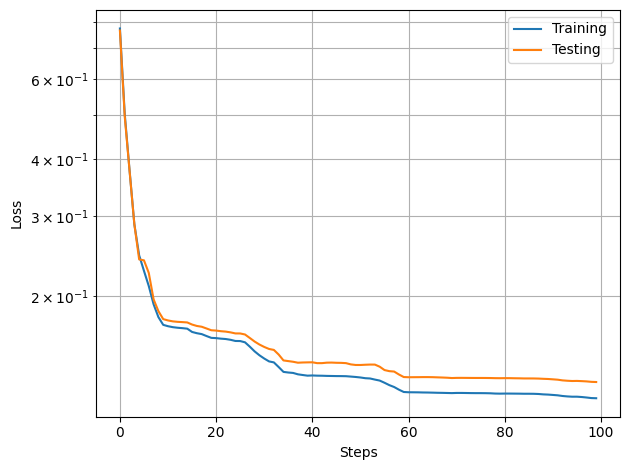

In [477]:
# HypPrm for training: opt (Adam, LBFGS), steps, lr, lamb
mykan.fit(dataset, steps=20, opt='LBFGS', lr=0.1, lamb=0.01, singularity_avoiding=True)
mykan.plot_training()
print()

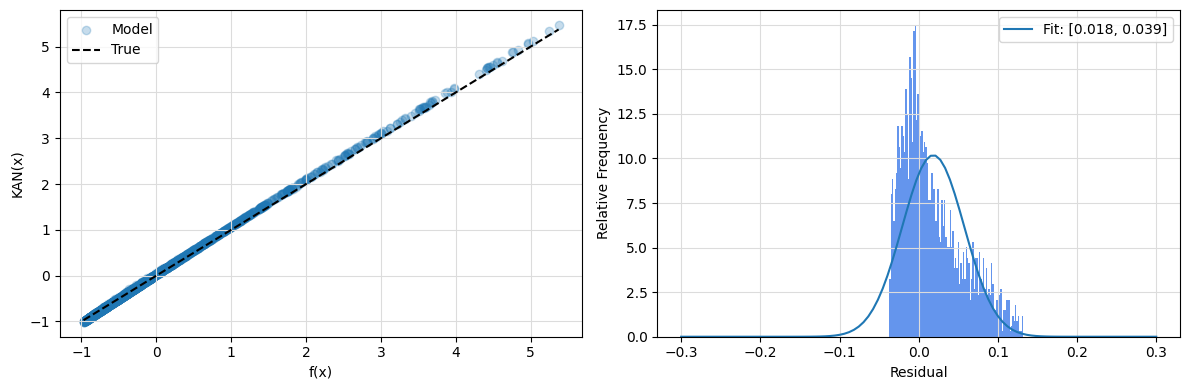

In [139]:
mykan.plot_performance(dataset)

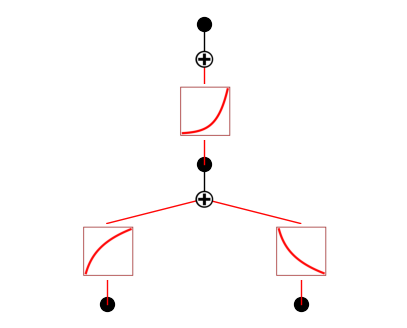

In [140]:
mykan.plot()

In [133]:
mykan.prune(node_th=0.03, edge_th=0.03)

saving model version 0.3
Edge pruning failed.


In [141]:
library = ['x','abs','1/x','exp','log']
mykan.model.auto_symbolic()
kan.utils.ex_round(mykan.model.symbolic_formula()[0][0], 4) # type:ignore

skipping (0,0,0) since already symbolic
skipping (0,1,0) since already symbolic
skipping (1,0,0) since already symbolic
saving model version 0.7


1.3655*(2.4119*x_1 + 5.212)**1.0/(4.1948*x_2 + 8.9111)**1.0 - 1.1097

In [142]:
for k,v in statistics.items():
    print(f"{k}: mu={v[0]}, sd={v[1]}")

train_input: mu=tensor([5.6121, 5.5164], device='cuda:0'), sd=tensor([2.5970, 2.5968], device='cuda:0')
test_input: mu=tensor([5.4737, 5.4898], device='cuda:0'), sd=tensor([2.6106, 2.6144], device='cuda:0')
train_label: mu=tensor([1.4135], device='cuda:0'), sd=tensor([1.2738], device='cuda:0')
test_label: mu=tensor([1.4277], device='cuda:0'), sd=tensor([1.3547], device='cuda:0')


In [143]:
mykan.evaluate_performance()

R2: 0.998128298526744	MAE: 0.03170820325020004	MSE: 0.0018707656225193782	AdjR2 0.9981264240135009	RMSE: 0.04325234817347352	MaxAE: 64.13934064145357


{'R2': 0.998128298526744,
 'MAE': 0.03170820325020004,
 'MSE': 0.0018707656225193782,
 'adjR2': 0.9981264240135009,
 'RMSE': 0.04325234817347352,
 'MaxAE': 64.13934064145357}

### [3] Compositions

In [302]:
# --- Create dataset
f = lambda x: torch.sqrt(torch.square(x[:,[0]] - x[:,[1]]) + torch.square(x[:,[2]] - x[:,[3]]))
dataset, statistics = generate_dataset(f, 4, 1, 8000, 2000, device='cuda:0', ranges=[[-10, 10]])

In [303]:
# HypPrm for initialization: width, spline order (k=3), grid intervals (grid=8), noise_scale, base_function (silu, identity, zero)
mykan = KanModel(dataset, [5,5], 'cuda:0', seed=43, k=4, grid=12, ckpt_path='./composition_model', base_fun='identity')

checkpoint directory created: ./composition_model
saving model version 0.0


In [314]:
mykan.fit(dataset, steps=40, opt='LBFGS', lr=.01, lamb=0.01)
print()

| train_loss: 4.19e-02 | test_loss: 3.80e-02 | reg: 1.15e+01 | : 100%|█| 40/40 [00:20<00:00,  1.98it

saving model version 0.5



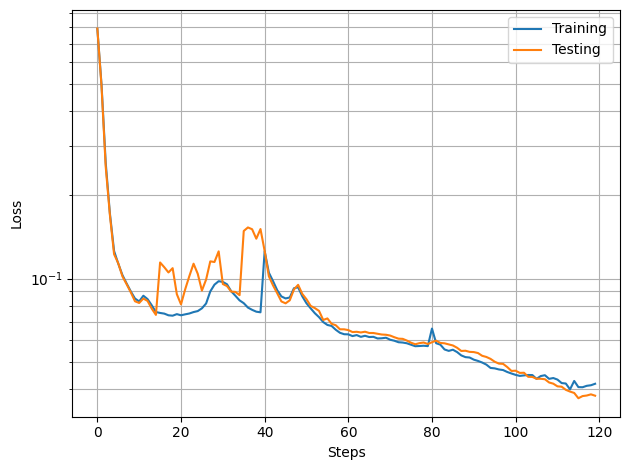

In [315]:
mykan.plot_training()
print()

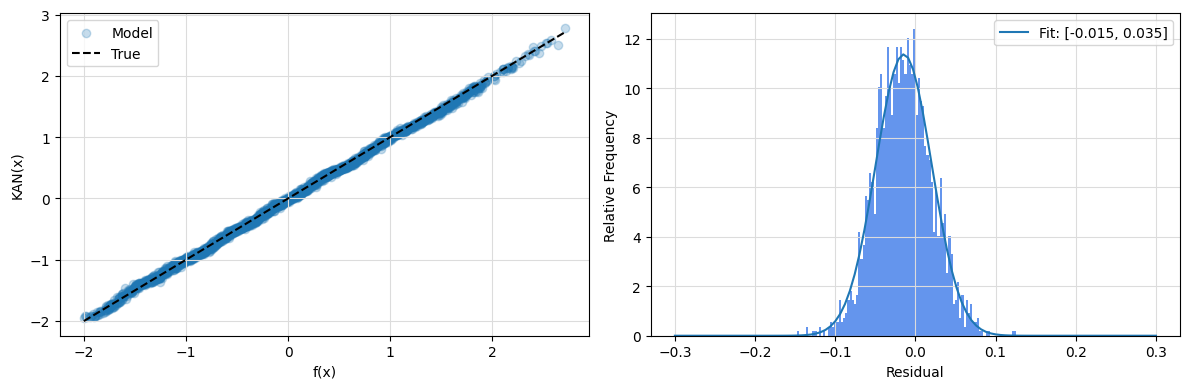

In [316]:
mykan.plot_performance(dataset)

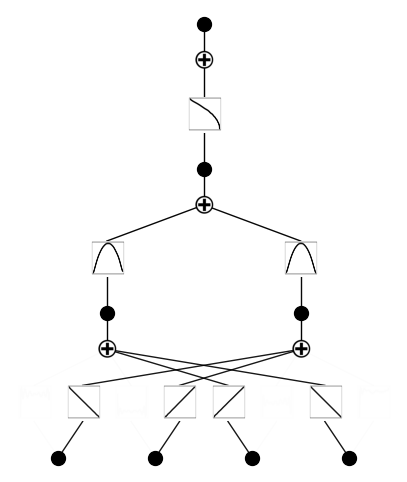

In [317]:
mykan.plot()

In [161]:
mykan.refine(num=8)

saving model version 0.3


saving model version 0.4
Edge pruning failed.


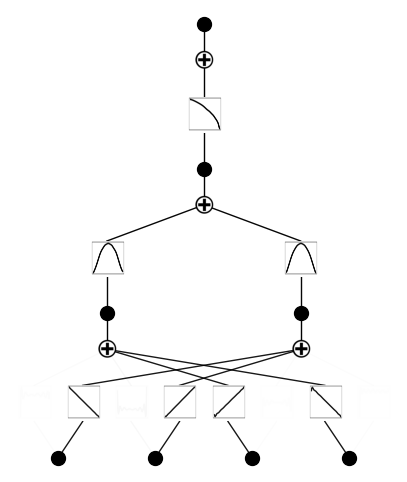

In [313]:
mykan.prune(node_th=0.09, edge_th=0.4)
mykan.plot()

In [319]:
mykan.model.auto_symbolic(lib=['x','x^2','sqrt'])
print()

fixing (0,0,0) with x, r2=0.00218188777101537, c=1
fixing (0,0,1) with x, r2=0.9999683099429885, c=1
fixing (0,1,0) with x, r2=0.0001981921453480466, c=1
fixing (0,1,1) with x, r2=0.9999639406376154, c=1
fixing (0,2,0) with x, r2=0.9999458216586119, c=1
fixing (0,2,1) with x, r2=0.0051889501305816136, c=1
fixing (0,3,0) with x, r2=0.9999984143347596, c=1
fixing (0,3,1) with x, r2=0.010635782914103373, c=1
fixing (1,0,0) with x^2, r2=0.999331025717137, c=2
fixing (1,1,0) with x^2, r2=0.9952650951115075, c=2
fixing (2,0,0) with sqrt, r2=0.9993251000096485, c=2
saving model version 0.6



In [320]:
kan.utils.ex_round(mykan.model.symbolic_formula()[0][0], 4) #type:ignore

3.2838*sqrt(0.5842*(0.0002*x_1 - 0.e-4*x_2 - 0.4401*x_3 + 0.4423*x_4 - 0.0072)**2 + 0.3801*(0.5439*x_1 - 0.5461*x_2 + 0.0003*x_3 - 0.0004*x_4 + 0.0407)**2 - 0.0114) - 1.9472

In [322]:
mykan.model = mykan.model.rewind('0.5')
mykan.evaluate_performance()

rewind to model version 0.5, renamed as 1.5
R2: 0.9985578540894282	MAE: 0.030390818162638458	MSE: 0.0014414248376164922	AdjR2 0.9985549625688055	RMSE: 0.037966101164281965	MaxAE: 87.79243749554236


{'R2': 0.9985578540894282,
 'MAE': 0.030390818162638458,
 'MSE': 0.0014414248376164922,
 'adjR2': 0.9985549625688055,
 'RMSE': 0.037966101164281965,
 'MaxAE': 87.79243749554236}

In [133]:
for k,v in statistics.items():
    print(f"{k}: mu={v[0]}, sd={v[1]}")

train_input: mu=tensor([5.6121, 5.5164, 5.4737, 5.4898], device='cuda:0'), sd=tensor([2.5970, 2.5968, 2.6106, 2.6144], device='cuda:0')
test_input: mu=tensor([5.6140, 5.5350, 5.5053, 5.5375], device='cuda:0'), sd=tensor([2.6116, 2.5940, 2.6014, 2.5928], device='cuda:0')
train_label: mu=tensor([4.7543], device='cuda:0'), sd=tensor([2.1984], device='cuda:0')
test_label: mu=tensor([4.6412], device='cuda:0'), sd=tensor([2.2688], device='cuda:0')


### [4] Phase

In [564]:
f = lambda x: torch.tanh(5*(x[:,[0]]**4 + x[:,[1]]**4 + x[:,[2]]**4 - 1))
dataset, statistics = generate_dataset(f, 3, 1, 20000, 2000, ranges=[[-1.2,1.2]], device='cuda:0')

In [565]:
# HypPrm for initialization: width, spline order (k=3), grid intervals (grid=8), noise_scale, base_function (silu, identity, zero)
mykan = KanModel(dataset, [5], 'cuda:0', seed=43, k=4, grid=8, base_fun='silu', ckpt_path='./phase_model', noise_scale=0.01, mult_arity=2)
myloss = torch.nn.L1Loss()

checkpoint directory created: ./phase_model
saving model version 0.0


In [607]:
# coarse training
mykan.fit(dataset, steps=20, opt='LBFGS', lr=.001, lamb=0.1, singularity_avoiding=True)
print()


| train_loss: 5.20e-06 | test_loss: 1.12e-01 | reg: 0.00e+00 | : 100%|█| 20/20 [00:00<00:00, 25.86it

saving model version 0.28



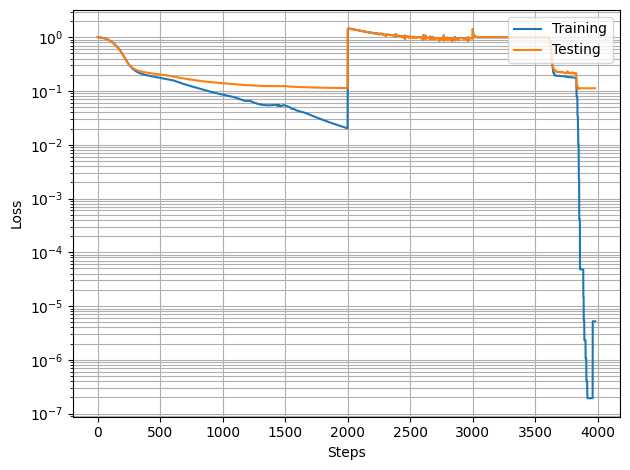

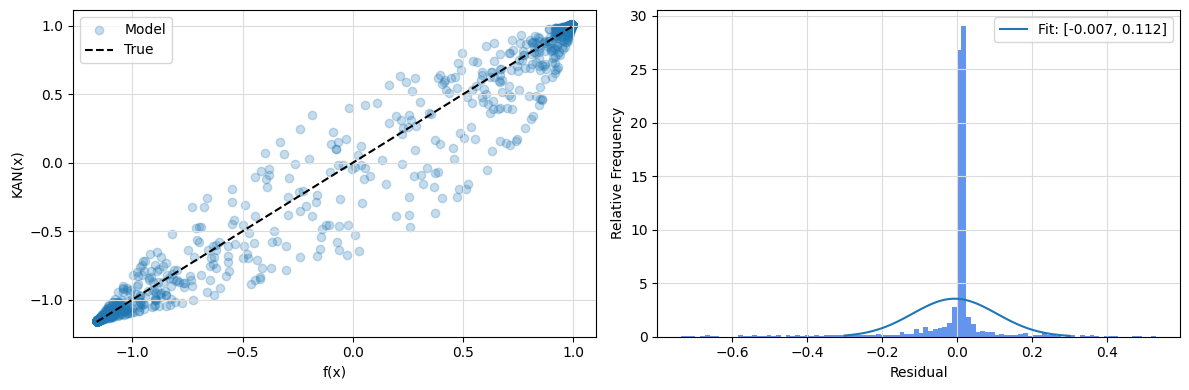

In [608]:
mykan.plot_training()
mykan.plot_performance()

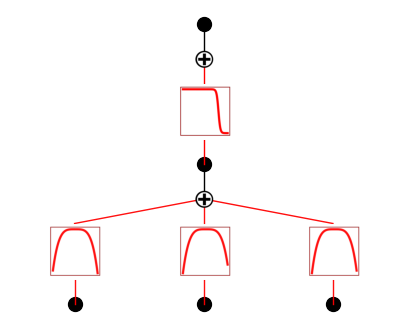

In [609]:
mykan.plot()

saving model version 0.2
Edge pruning failed.


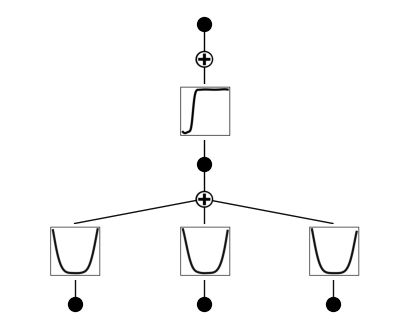

In [569]:
# pruning
mykan.prune(node_th=0.05)
mykan.prune(edge_th=0.10)

mykan.plot()

In [588]:
mykan.model.refine(16)
print()

saving model version 0.16



In [562]:
mykan.model.rewind('0.8')
print()

rewind to model version 2.8, renamed as 3.8



fixing (0,0,0) with x^4, r2=0.9971394955501081, c=3
fixing (0,1,0) with x^4, r2=0.9939318134260909, c=3
fixing (0,2,0) with x^4, r2=0.9968232898764284, c=3
fixing (1,0,0) with tanh, r2=0.996869682441667, c=3
saving model version 0.3


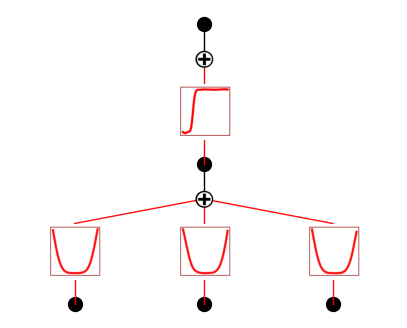

In [570]:
# symbols
mykan.model.auto_symbolic(lib=['x^4','tanh'])
mykan.plot()

In [610]:
kan.utils.ex_round(mykan.model.symbolic_formula()[0][0], 4) #type:ignore

1.0819*tanh(0.0004*(-7.3972*x_1 - 0.069)**4 + 0.0002*(-8.9525*x_2 - 0.0008)**4 + 0.0009*(-5.9738*x_3 - 0.0026)**4 - 5.0) - 0.0744

In [611]:
mykan.evaluate_performance()

R2: 0.9873592127520698	MAE: 0.04774578246176917	MSE: 0.012634466854306211	AdjR2 0.9873402135728395	RMSE: 0.11240314432570919	MaxAE: 25.366180533893836


{'R2': 0.9873592127520698,
 'MAE': 0.04774578246176917,
 'MSE': 0.012634466854306211,
 'adjR2': 0.9873402135728395,
 'RMSE': 0.11240314432570919,
 'MaxAE': 25.366180533893836}